R# Experiment 1 — End-to-End: WebAggr vs. Baseline Agents

## Summary (what this experiment does, in plain language)

**Question.** Given the same dollar budget, does the full WebAggr pipeline reassemble
ground truth with *higher recall*, *lower aggregation error*, and *honest confidence*
than simpler agents?

**Claims defended** (design doc `webaggr.pdf`):
- **C14** (§1, §2.3): today's agents return plausible but *uncertifiable* answers, and
  coverage is not contribution — a system can *see* the right pages and still report the
  wrong total.
- **C2** (§3.3, Def. 6): WebAggr's stopping rule fires at sane budgets — when it stops,
  realized recall is at least `1 − ε`.

**The test.** We use the paper's central instrument (§9): the **withheld-registry oracle**.
Ground truth is built from SEC EDGAR Form D filings (the registry); the agents must then
reassemble each company's private funding history from the *open web only* — every
`sec.gov` host is denied to them. Because we hold the answer key, we can grade exactly
what each system got right, got wrong, and made up.

**Four systems, same queries, same search backend, same LLMs, same dollar budget:**

| # | System | What it keeps | What it lacks |
|---|--------|---------------|----------------|
| 1 | **WebAggr** (full pipeline) | everything: adaptive frontier + stopping rule, corroboration, ER, checksums, honest interval | — |
| 2 | **Fixed-budget crawler** | the *same* search / fetch / extract stack | no stopping rule (stops when money runs out), majority-vote dedup instead of corroboration + ER |
| 3 | **Generic LLM research agent** | a strong LLM with a search tool, prompted for the same table | no statistical machinery at all — the "just ask an agent" baseline |
| 4 | **Naive sum** | the crawler's harvest | no dedup of any kind: sums **every** extracted mention |

**Grading (identical for all four).** Each system's asserted funding rounds are aligned
one-to-one with the registry's answer key, then we report per company:
- **record recall** — what fraction of the true rounds did the system find?
- **value recall** — what fraction of the true *dollars* did the found rounds cover?
- **relative aggregation error** — how far is the reported total from the true total?
- **cost** — realized spend (searches + LLM tokens) under one shared price table.
- For WebAggr only: the **certificate** each group ends with
  (statistical / checksum / registry / abandoned) and whether its stated interval
  actually contains the truth ("honest confidence").

**Expected result.** WebAggr matches or beats the baselines on recall at equal cost and
wins big on aggregation error. **Pre-registered bad outcomes** (reported honestly if they
happen): the crawler ties WebAggr (the machinery isn't paying for itself), or WebAggr's
recall is fine but everything ends "abandoned" (guarantees too conservative to be useful).

**Why it matters.** This is the thing a reviewer cares about first — it answers
"why not just use a normal agent?" — and its live runs are frozen to disk, so several
later experiments (2, 4, 7, 9) can be re-run offline from these logs without new spend.

## Design notes — deviations from the proposal (and why)

Three deliberate improvements over the literal proposal text, decided **before** any run:

1. **One harvest, two baselines.** The fixed-budget crawler (system 2) and the naive sum
   (system 4) share the *identical* search → fetch → extract harvest; they differ only in
   the final aggregation step (majority-vote dedup vs. no dedup). Running the harvest once
   and deriving both answers isolates exactly the mechanism under test (§2.3: coverage vs.
   contribution) and halves live spend — the evidence is the same, only the reasoning differs.
2. **Matched realized cost, not nominal budget.** WebAggr runs first under the frozen
   certification config. Its *realized* dollar cost per company (searches + LLM tokens,
   one price table) then becomes the hard spend cap for each baseline on that company.
   "Same budget" is thereby exact and auditable per entity, not a config value that one
   system under-spends.
3. **Baselines face the same denylist and the same offline verifier.** Every baseline
   harvest runs behind the same `sec.gov` denylist, persists its sources to a run DB, and
   is checked by the same `assert_no_denied_sources` audit as WebAggr — a baseline that
   peeked at the registry would invalidate the comparison in *its own favor*.

**Integrity notes.**
- The **validation half (18 entities)** is used for all grading, per the proposal's shared
  setup; the calibration half stays reserved for the εF certificate (Experiment 6). Nothing
  is tuned after seeing validation results — runs are graded once, and failures are findings.
- The pipeline configuration is the **frozen A3 certification config** (ε=0.10, δ=0.10,
  60 steps, $5 search cap, amount+date attributes, equity-scoped query template). εF is
  currently the labelled App.-H fallback (the certificate is NOT CERTIFIED yet) — the
  report layer tags this provenance honestly, and these results are *preliminary* until
  the fidelity certificate lands. If the config later changes under a pre-registered
  addendum, these runs must be repeated under it.
- **This notebook spends real money** (Serper + OpenAI). It is resumable: every
  system × entity result is written to a ledger the moment it's graded, and finished work
  is never re-run. Discuss the projected spend (printed below) with your supervisor
  before flipping `RUN_LIVE = True`.

## 1 · Setup

Load the repo, check API keys, and echo the frozen configuration. Nothing here spends money.

In [1]:
import os, sys, json, math, time, uuid, traceback
from pathlib import Path
from collections import defaultdict, Counter
from types import SimpleNamespace as NS

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":            # allow running from notebooks/ or repo root
    REPO = REPO.parent
sys.path.insert(0, str(REPO))
os.chdir(REPO)                          # relative paths ("prompts/...") resolve
                                        # against the CWD, and the package assumes
                                        # repo root — same assumption as the CLI

from webagg import config                                  # loads .env
from webagg.certify import (REGISTRY_DENY, CERT_ATTRS,     # frozen cert conventions
                            entity_query, query_name)      # (webaggr.pdf Sec. 9 oracle)
from webagg.formd import load_truth_cohort
from webagg.risk_control import match_to_truth, usd

# real keys or stop now — this experiment has no offline mode (no dummies).
assert config.SERPER_API_KEY, "SERPER_API_KEY missing from .env"
import os; assert os.environ.get("OPENAI_API_KEY"), "OPENAI_API_KEY missing from .env"

COHORT     = "formd_v2"                                    # the frozen cohort
COHORT_DIR = config.GROUND_TRUTH_DIR / COHORT
EXP_DIR    = config.DATA_DIR / "experiments" / "exp1"      # ledger + tables
FIG_DIR    = REPO / "figures" / "exp1"                     # paper-ready figures
for d in (EXP_DIR, EXP_DIR / "ledger", FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Frozen run configuration = the A3 certification config (comparability with
# the reference runs; changing any of these mid-experiment would be tuning).
RUN_CFG = dict(eps=0.10, delta=0.10, max_steps=60, budget_usd=config.BUDGET_USD)
print("frozen config :", RUN_CFG)
print("denied hosts  :", REGISTRY_DENY, " (webaggr.pdf Sec. 9: the withheld registry)")
print("query attrs   :", sorted(CERT_ATTRS))
print("grading tol   :", config.GRADING_AMOUNT_TOL, " (pre-registered amount-primary key)")
print("models        :", config.MODEL_CHEAP, "/", config.MODEL_STRONG)

frozen config : {'eps': 0.1, 'delta': 0.1, 'max_steps': 60, 'budget_usd': 5.0}
denied hosts  : ('sec.gov', 'www.sec.gov', 'data.sec.gov')  (webaggr.pdf Sec. 9: the withheld registry)
query attrs   : ['amount', 'date']
grading tol   : 0.05  (pre-registered amount-primary key)
models        : gpt-5-nano / gpt-5


## 2 · The cohort and its answer key

We load the frozen `formd_v2` cohort (52 companies whose full private-funding history is
in SEC EDGAR) and keep only the **validation half — 18 companies** never used for any
calibration. Each company's open-web query uses the *common* name the press uses
(from the frozen screening sheet), not the registry's legal name — asking the web about
"Outreach Corp" probes a name, not a pipeline.

In [2]:
# Step 2: answer key + validation split + common names (all frozen artifacts).
import csv

manifest = json.loads((COHORT_DIR / "manifest.json").read_text())
truths   = load_truth_cohort(COHORT_DIR)          # entity_id -> TruthEntity answer key
VAL      = list(manifest["split"]["validation"])  # the 18 grading entities

# common names come from the frozen cohort screen (decided before any run —
# deriving them here, not hand-typing them, keeps this un-tunable).
common = {}
with open(config.GROUND_TRUTH_DIR / "cohort_screen.csv", newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        if row["cik"]:
            common["cik" + row["cik"]] = row["candidate"]
NAMES = {eid: common[eid] for eid in VAL}         # KeyError here = frozen-artifact bug: stop

print(f"validation half: {len(VAL)} entities")
for eid in VAL:
    t = truths[eid]
    print(f"  {eid}  {NAMES[eid]:<28} true rounds={t.true_count:>2}  "
          f"true SUM=${t.true_sum/1e6:,.1f}M")

validation half: 18 entities
  cik0001537182  Outreach                     true rounds=14  true SUM=$490.0M
  cik0001577481  Highspot                     true rounds= 8  true SUM=$653.8M
  cik0001595931  Pendo                        true rounds= 9  true SUM=$368.3M
  cik0001601830  Recursion Pharmaceuticals    true rounds= 9  true SUM=$478.4M
  cik0001613287  Canopy Tax                   true rounds= 8  true SUM=$155.9M
  cik0001614167  FullStory                    true rounds= 7  true SUM=$197.3M
  cik0001722207  LinkSquares                  true rounds= 6  true SUM=$160.2M
  cik0001783735  Delfi Diagnostics            true rounds= 5  true SUM=$365.9M
  cik0001792473  Matik                        true rounds= 2  true SUM=$23.1M
  cik0001796214  Dusty Robotics               true rounds= 3  true SUM=$66.9M
  cik0001813993  Quaise Energy                true rounds= 5  true SUM=$262.4M
  cik0001817057  Second Front Systems         true rounds= 4  true SUM=$125.1M
  cik0001824134  BioIntel

## 3 · One price table, one cost meter

"Same dollar budget" only means something if every system's spend is priced the same way.
One table prices searches and LLM tokens; one function reads any run's database and
returns its realized cost. A model missing from the table **fails loudly** — silently
pricing it at zero would corrupt the equal-cost claim.

In [3]:
# Step 3: unified cost accounting (searches + LLM tokens; one source of truth).
from sqlalchemy import func
from webagg.storage import (get_session, MeasurementRow,
                            FrontierFormulationRow, SourceRow, MentionRow)

# USD per 1M tokens (input, output). VERIFY against the provider's live price
# sheet on the day of the paper run and update here if it moved.
LLM_PRICE_PER_MTOK = {
    "gpt-5-nano": (0.05, 0.40),
    "gpt-5":      (1.25, 10.00),
}
SEARCH_COST = config.SEARCH_COST_USD                       # $ per search issuance


def llm_cost_usd(model: str, tok_in: int, tok_out: int) -> float:
    """Price one LLM call. Unknown model = loud failure, never $0."""
    if model not in LLM_PRICE_PER_MTOK:
        raise KeyError(f"model {model!r} missing from LLM_PRICE_PER_MTOK — "
                       f"add its price before running (no silent zero-pricing)")
    pin, pout = LLM_PRICE_PER_MTOK[model]
    return (tok_in * pin + tok_out * pout) / 1e6


def run_cost_from_db(db_path: str, run_id: str) -> dict:
    """Realized spend of a finished run, read from its own database.

    Every system logs the same way (searches -> formulations table or an
    explicit 'search_issued' row; LLM calls -> 'llm_call' measurement rows
    with model + token counts), so this one function prices them all.
    """
    s = get_session(db_path)
    try:
        n_search = (s.query(FrontierFormulationRow)
                     .filter_by(run_id=run_id, issued=1).count())
        n_search += (s.query(MeasurementRow)
                      .filter_by(run_id=run_id, metric="search_issued").count())
        llm = 0.0
        tok = {"in": 0, "out": 0}
        for r in s.query(MeasurementRow).filter_by(run_id=run_id, metric="llm_call"):
            e = r.extra or {}
            llm += llm_cost_usd(e.get("model", ""), e.get("input_tokens", 0),
                                e.get("output_tokens", 0))
            tok["in"] += e.get("input_tokens", 0); tok["out"] += e.get("output_tokens", 0)
        return {"searches": n_search, "search_usd": n_search * SEARCH_COST,
                "llm_usd": llm, "tokens": tok,
                "total_usd": n_search * SEARCH_COST + llm}
    finally:
        eng = s.get_bind(); s.close(); eng.dispose()       # Windows: release sqlite lock

print("price table:", LLM_PRICE_PER_MTOK, "| search:", f"${SEARCH_COST}/query")

price table: {'gpt-5-nano': (0.05, 0.4), 'gpt-5': (1.25, 10.0)} | search: $0.02/query


## 4 · One grading function for all four systems

Each system ends with a list of asserted funding rounds. We align them **one-to-one**
with the registry's answer key under the **pre-registered amount-primary grading key**
(the exact rule frozen in `PREREGISTRATION.md` before any reference run — press quotes
announcement dates while the registry files legal dates, so amounts, not dates, carry the
alignment). A truth round can absorb at most one asserted record; everything unmatched is
**spurious** and counts against the system at full value.

In [4]:
# Step 4: grading (webaggr.pdf Sec. 9: grade what the agent reassembles).
def _wrap(rec: dict) -> dict:
    """Baseline record -> the dict shape match_to_truth reads.

    WebAggr records already have this shape; baselines assert plain
    numbers, so we wrap each attribute in a tiny value object.
    """
    attrs = {}
    if rec.get("amount") is not None:
        attrs["amount"] = NS(value_num=float(rec["amount"]), value=str(rec["amount"]))
    if rec.get("date"):
        attrs["date"] = NS(value=str(rec["date"]), value_num=None)
    return {"record_kind": rec.get("record_kind", "funding_round"), "attributes": attrs}


def grade(records, truth, est_sum=None) -> dict:
    """Score one system on one company against the registry answer key.

    records: list of dicts {"amount", "date", "record_kind"} OR WebAggr's
             native resolved records (passed through untouched).
    est_sum: the total the system *reports*; defaults to the sum of its
             asserted record amounts (true for every baseline).
    """
    recs = [r if isinstance(r, dict) and "attributes" in r else _wrap(r)
            for r in records]
    aligned = match_to_truth(recs, truth,                       # pre-registered key:
                             amount_tol=config.GRADING_AMOUNT_TOL,
                             amount_primary=True)               # registry>amount>date
    matched = [(r, t) for r, t in aligned if t is not None]
    if est_sum is None:
        est_sum = sum(usd(r["attributes"].get("amount")) for r in recs)
    tc, ts = truth.true_count, truth.true_sum
    return {
        "n_asserted":    len(recs),
        "n_matched":     len(matched),
        "n_spurious":    len(recs) - len(matched),
        "record_recall": len(matched) / tc if tc else 1.0,      # rounds found
        "value_recall":  (sum(t.amount for _, t in matched) / ts) if ts else 1.0,
        "est_sum":       float(est_sum),
        "true_sum":      float(ts),
        "rel_error":     abs(est_sum - ts) / ts if ts else 0.0, # aggregation error
    }


# ledger: one JSON per system x entity; finished work is never re-run.
def ledger_path(system: str, eid: str) -> Path:
    return EXP_DIR / "ledger" / f"{system}_{eid}.json"

def ledger_load(system: str, eid: str):
    p = ledger_path(system, eid)
    return json.loads(p.read_text()) if p.exists() else None

def ledger_save(system: str, eid: str, payload: dict):
    payload = {"system": system, "entity_id": eid,
               "saved_at": time.strftime("%Y-%m-%dT%H:%M:%S"), **payload}
    ledger_path(system, eid).write_text(json.dumps(payload, indent=2, default=str))
    return payload

print("grading + ledger ready")

grading + ledger ready


## 5 · Projected spend, then explicit consent

Before spending anything, we *project* the bill from real prior spend: the 34 calibration
reference runs already on disk tell us what one WebAggr entity actually costs. The three
baselines are each capped at WebAggr's realized cost, so the whole experiment costs
roughly **4 × (WebAggr's per-entity cost) × 18 entities**, minus whatever is already in
the ledger. Live spend only happens after you set `RUN_LIVE = True`.

In [5]:
# Step 5: price the experiment from real prior runs (no guessing where data exists).
from webagg.certify import load_runs_index

cal_costs = []
for eid, info in load_runs_index(COHORT).items():          # the 34 A3 reference runs
    db = Path(info["db"])
    if db.exists():
        try:
            cal_costs.append(run_cost_from_db(str(db), info["run_id"])["total_usd"])
        except KeyError as e:
            print("  (skipped one cal run:", e, ")")

if cal_costs:
    cal_costs.sort()
    per_entity = cal_costs[len(cal_costs) // 2]            # median real cost
    print(f"median realized cost of a reference run: ${per_entity:.2f} "
          f"(from {len(cal_costs)} real A3 runs)")
else:                                                       # fresh machine: bound it
    per_entity = RUN_CFG["budget_usd"] + 1.50               # search cap + LLM headroom
    print(f"no local reference runs found — using conservative ${per_entity:.2f}/entity")

done = sum(1 for s in ("webaggr", "harvest", "llm_agent")
             for e in VAL if ledger_load(s, e))
todo_webaggr = sum(1 for e in VAL if not ledger_load("webaggr", e))
todo_harvest = sum(1 for e in VAL if not ledger_load("harvest", e))
todo_agent   = sum(1 for e in VAL if not ledger_load("llm_agent", e))
projected = per_entity * (todo_webaggr + todo_harvest + todo_agent)
print(f"remaining live work: webaggr={todo_webaggr}  harvest={todo_harvest}  "
      f"llm_agent={todo_agent}  (ledger already holds {done})")
print(f"PROJECTED REMAINING SPEND ~= ${projected:,.2f}")
print("-> confirm this figure with your supervisor before proceeding.")

no local reference runs found — using conservative $6.50/entity
remaining live work: webaggr=18  harvest=18  llm_agent=18  (ledger already holds 0)
PROJECTED REMAINING SPEND ~= $351.00
-> confirm this figure with your supervisor before proceeding.


In [6]:
# Step 5b: the consent gate. Nothing below this cell spends money until this is True.
RUN_LIVE = True   # <- flip to True to run the experiment for real

if not RUN_LIVE:
    print("RUN_LIVE is False: live cells below will load ledger results only.")

## 6 · System 1 — WebAggr (the full pipeline)

For each of the 18 companies, run the complete pipeline **live** with the registry denied:
adaptive search frontier with the anytime-valid stopping rule (§3), corroboration that
counts evidence rather than copies (§4), checksums (§5), entity resolution (§6), and the
certified reader + honest two-term interval (§7). Each run freezes its full evidence pool
to a SQLite database — later experiments replay these offline. WebAggr runs first because
its *realized* cost defines every baseline's budget.

Each finished run is verified clean (`assert_no_denied_sources`: not one byte from
`sec.gov`), graded against the answer key, and written to the ledger.

In [7]:
# Step 6: WebAggr live runs (webaggr.pdf Sec. 3-7 end-to-end; Sec. 9 protocol).
from webagg import pipeline
from webagg.denylist import Denylist, assert_no_denied_sources
from webagg.fetch import clear_fetch_cache

def run_webaggr(eid: str) -> dict:
    name   = NAMES[eid]
    run_id = f"exp1_webaggr_{eid}"
    db     = config.RUNS_DIR / f"{run_id}.sqlite"
    db.unlink(missing_ok=True)                 # stale-output lesson: never append
    clear_fetch_cache()                        # caches are per-run, like the DB

    out = pipeline.end_to_end(                 # one call = the whole paper
        entity_query(name),                    # frozen equity-scoped query (Sec. 9)
        run_id=run_id,
        query_attributes=set(CERT_ATTRS),      # amount feeds the loss, date the key
        aggregate_attr="amount",
        deny=REGISTRY_DENY,                    # the withheld registry (Sec. 9)
        domain=COHORT,                         # eps_F provenance tag (Sec. 7.2/App. H)
        **RUN_CFG)                             # frozen eps/delta/steps/budget

    # integrity: refuse a contaminated run before grading it (Sec. 9).
    s = get_session(str(db))
    try:
        assert_no_denied_sources(s, Denylist(REGISTRY_DENY))
    finally:
        eng = s.get_bind(); s.close(); eng.dispose()

    g   = grade(out["records"], truths[eid],
                est_sum=out["report"]["__global__"]["total"])   # grade what it REPORTS
    rep = out["report"]
    groups = {k: {"regime": v["regime"], "certificate": v["certificate"],
                  "total": v["total"], "halfwidth": v["halfwidth"]}
              for k, v in rep.items() if not k.startswith("__")}
    glob = rep["__global__"]
    hw   = glob["halfwidth"]
    return ledger_save("webaggr", eid, {
        "entity_name": name, "run_id": run_id, "db": str(db), **g,
        "cost": run_cost_from_db(str(db), run_id),
        "groups": groups,                               # per-group certificates
        "abandoned": sorted(rep["__abandoned__"]),
        "interval": {"total": glob["total"], "halfwidth": hw,
                     "eps_C": glob["eps_C"], "eps_F": glob["eps_F"],
                     "eps_F_source": glob["eps_F_source"],
                     # honest confidence: does the stated interval cover truth?
                     "covers_truth": (hw is not None and
                                      abs(glob["total"] - truths[eid].true_sum) <= hw)},
    })


for eid in VAL:
    if ledger_load("webaggr", eid):
        print(f"[webaggr] {eid} ({NAMES[eid]}): done — skip"); continue
    if not RUN_LIVE:
        print(f"[webaggr] {eid} ({NAMES[eid]}): pending (RUN_LIVE=False)"); continue
    print(f"[webaggr] {eid} ({NAMES[eid]}): LIVE run ...")
    try:
        r = run_webaggr(eid)
        print(f"           recall={r['record_recall']:.2f}  "
              f"rel_err={r['rel_error']:.2%}  cost=${r['cost']['total_usd']:.2f}")
    except Exception:
        traceback.print_exc()                  # loud, but one failure never
        print(f"[webaggr] {eid}: FAILED — continuing (re-run this cell to retry)")

[webaggr] cik0001537182 (Outreach): LIVE run ...
[er] matcher fitted on 280 labeled pairs (37 same / 243 different); alpha=0.1321


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

           recall=0.21  rel_err=25.71%  cost=$0.73
[webaggr] cik0001577481 (Highspot): LIVE run ...
[er] matcher fitted on 280 labeled pairs (37 same / 243 different); alpha=0.1321
           recall=0.25  rel_err=31.48%  cost=$0.48
[webaggr] cik0001595931 (Pendo): LIVE run ...
[er] matcher fitted on 280 labeled pairs (37 same / 243 different); alpha=0.1321
           recall=0.44  rel_err=72.85%  cost=$1.17
[webaggr] cik0001601830 (Recursion Pharmaceuticals): LIVE run ...
[er] matcher fitted on 280 labeled pairs (37 same / 243 different); alpha=0.1321
           recall=0.33  rel_err=103.57%  cost=$1.41
[webaggr] cik0001613287 (Canopy Tax): LIVE run ...
[er] matcher fitted on 280 labeled pairs (37 same / 243 different); alpha=0.1321
           recall=0.38  rel_err=100.00%  cost=$1.20
[webaggr] cik0001614167 (FullStory): LIVE run ...
[er] matcher fitted on 280 labeled pairs (37 same / 243 different); alpha=0.1321
           recall=0.71  rel_err=58.44%  cost=$0.98
[webaggr] cik0001722207 (

## 7 · Shared harvest for the crawler and the naive sum

The two non-agentic baselines share one harvest per company: a fixed, pre-registered list
of query templates is issued round-robin through the **same** search backend, pages are
fetched and passed through the **same** relevance filter and certified extractor as
WebAggr (§7.1) — behind the **same** denylist. The harvest stops when it has spent
WebAggr's realized cost for that company. What the baselines *lack* is everything after
extraction: no stopping statistics, no corroboration, no entity resolution, no checksums.

The harvest is saved once; systems 2 and 4 are then derived from it offline.

In [8]:
# Step 7: crawler-stack harvest (same fetch/read stack as WebAggr; webaggr.pdf
# Sec. 2.3 -- the point is that seeing the pages is not the hard part).
from webagg.search import SerperBackend
from webagg.fetch import fetch_url
from webagg.extract import is_relevant, extract_certified
from webagg.calibration import ConformalGate, load_calibration_set
from webagg.denylist import set_denylist, get_denylist, clear_denylist
from webagg.llm import set_llm_logger
from webagg.metrics import log_measurement

# frozen template list (decided before any run; edits after seeing results = tuning)
CRAWL_TEMPLATES = [
    "{name} funding rounds",
    "{name} raises seed round",
    "{name} raises series a",
    "{name} raises series b",
    "{name} raises series c million",
    "{name} total funding raised",
    "{name} venture capital investment",
    "{name} startup funding announcement",
]

def _fitted_gate() -> ConformalGate:
    """Same calibrated reader as the pipeline (Sec. 7.1, Prop. 2)."""
    gate = ConformalGate(delta_E=config.DELTA_E)
    cal = load_calibration_set(config.CALIBRATION_SET)
    if cal:
        gate.fit(cal)
    return gate


def run_harvest(eid: str, cap_usd: float) -> dict:
    name   = NAMES[eid]
    run_id = f"exp1_harvest_{eid}"
    db     = config.RUNS_DIR / f"{run_id}.sqlite"
    db.unlink(missing_ok=True)
    clear_fetch_cache()
    set_denylist(REGISTRY_DENY)                # same withheld registry as WebAggr
    session = get_session(str(db))
    set_llm_logger(session, run_id)            # LLM tokens land in THIS run's DB
    gate    = _fitted_gate()
    search  = SerperBackend()
    mentions, ti = [], 0
    try:
        while True:
            # price the next search BEFORE issuing it (hard cap, but >=1 search)
            spent = (run_cost_from_db_open(session, run_id)
                     if ti else 0.0)
            if ti and spent + SEARCH_COST > cap_usd:
                break
            q = CRAWL_TEMPLATES[ti % len(CRAWL_TEMPLATES)].format(name=name)
            ti += 1
            log_measurement(session, run_id, ti, "search_issued", 1.0,
                            extra={"query": q}); session.commit()
            for hit in search.search(q, k=10, formulation_id=f"crawl{ti}"):
                if get_denylist().blocks(hit["url"]):
                    continue                    # drop registry hits pre-fetch
                src = fetch_url(hit["url"], formulation_id=f"crawl{ti}")
                if src is None:
                    continue
                session.add(src.to_row()); session.commit()   # auditable pool
                ok, _conf = is_relevant(src, entity_query(name))
                if not ok:
                    continue
                ms, _claims, _info = extract_certified(       # same certified
                    src, entity_query(name), gate=gate)       # reader (Sec. 7.1)
                for m in ms:
                    session.add(m.to_row()); mentions.append(m)
                session.commit()
                if run_cost_from_db_open(session, run_id) >= cap_usd:
                    break                       # LLM spend can also end the run
            if run_cost_from_db_open(session, run_id) >= cap_usd:
                break
        assert_no_denied_sources(session, Denylist(REGISTRY_DENY))
        cost = run_cost_from_db_open(session, run_id)
    finally:
        session.commit()
        eng = session.get_bind(); session.close(); eng.dispose()
        clear_denylist()

    dump = [{"entity_surface": m.entity_surface, "record_kind": m.record_kind,
             "attribute": m.attribute, "value": m.value, "value_num": m.value_num,
             "source_id": m.source_id} for m in mentions]
    full = run_cost_from_db(str(db), run_id)
    return ledger_save("harvest", eid, {
        "entity_name": name, "run_id": run_id, "db": str(db),
        "cap_usd": cap_usd, "cost": full, "n_searches": full["searches"],
        "n_mentions": len(dump), "mentions": dump})


def run_cost_from_db_open(session, run_id: str) -> float:
    """Live spend of an in-progress run (same pricing as run_cost_from_db)."""
    n = (session.query(MeasurementRow)
                .filter_by(run_id=run_id, metric="search_issued").count())
    llm = 0.0
    for r in session.query(MeasurementRow).filter_by(run_id=run_id, metric="llm_call"):
        e = r.extra or {}
        llm += llm_cost_usd(e.get("model", ""), e.get("input_tokens", 0),
                            e.get("output_tokens", 0))
    return n * SEARCH_COST + llm


for eid in VAL:
    if ledger_load("harvest", eid):
        print(f"[harvest] {eid} ({NAMES[eid]}): done — skip"); continue
    wa = ledger_load("webaggr", eid)
    if wa is None:
        print(f"[harvest] {eid}: waiting for WebAggr run (defines the budget)"); continue
    if not RUN_LIVE:
        print(f"[harvest] {eid} ({NAMES[eid]}): pending (RUN_LIVE=False)"); continue
    cap = wa["cost"]["total_usd"]              # matched realized cost (design note 2)
    print(f"[harvest] {eid} ({NAMES[eid]}): LIVE, cap=${cap:.2f} ...")
    try:
        r = run_harvest(eid, cap)
        print(f"           searches={r['n_searches']}  mentions={r['n_mentions']}  "
              f"spent=${r['cost']['total_usd']:.2f}")
    except Exception:
        traceback.print_exc()
        print(f"[harvest] {eid}: FAILED — continuing")

[harvest] cik0001537182 (Outreach): LIVE, cap=$0.73 ...


Traceback (most recent call last):
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\engine\base.py", line 1969, in _exec_single_context
    self.dialect.do_execute(
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\engine\default.py", line 952, in do_execute
    cursor.execute(statement, parameters)
sqlite3.IntegrityError: UNIQUE constraint failed: sources.source_id

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Users\wangz\AppData\Local\Temp\ipykernel_43772\2072744694.py", line 61, in run_harvest
    session.add(src.to_row()); session.commit()   # auditable pool
                               ^^^^^^^^^^^^^^^^
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\orm\session.py", line 2035, in commit
    trans.commit(_to_root=True)
  File "<string>", line 2, in commit
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-

[harvest] cik0001537182: FAILED — continuing
[harvest] cik0001577481 (Highspot): LIVE, cap=$0.48 ...


Traceback (most recent call last):
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\engine\base.py", line 1969, in _exec_single_context
    self.dialect.do_execute(
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\engine\default.py", line 952, in do_execute
    cursor.execute(statement, parameters)
sqlite3.IntegrityError: UNIQUE constraint failed: sources.source_id

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Users\wangz\AppData\Local\Temp\ipykernel_43772\2072744694.py", line 61, in run_harvest
    session.add(src.to_row()); session.commit()   # auditable pool
                               ^^^^^^^^^^^^^^^^
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\orm\session.py", line 2035, in commit
    trans.commit(_to_root=True)
  File "<string>", line 2, in commit
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-

[harvest] cik0001577481: FAILED — continuing
[harvest] cik0001595931 (Pendo): LIVE, cap=$1.17 ...


...

Traceback (most recent call last):
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\engine\base.py", line 1969, in _exec_single_context
    self.dialect.do_execute(
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\engine\default.py", line 952, in do_execute
    cursor.execute(statement, parameters)
sqlite3.IntegrityError: UNIQUE constraint failed: sources.source_id

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Users\wangz\AppData\Local\Temp\ipykernel_43772\2072744694.py", line 61, in run_harvest
    session.add(src.to_row()); session.commit()   # auditable pool
                               ^^^^^^^^^^^^^^^^
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\orm\session.py", line 2035, in commit
    trans.commit(_to_root=True)
  File "<string>", line 2, in commit
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-

[harvest] cik0001870184: FAILED — continuing
[harvest] cik0001880409 (Dagger): LIVE, cap=$0.10 ...
           searches=1  mentions=5  spent=$0.10
[harvest] cik0001973707 (Castelion): LIVE, cap=$1.84 ...


Traceback (most recent call last):
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\engine\base.py", line 1969, in _exec_single_context
    self.dialect.do_execute(
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\engine\default.py", line 952, in do_execute
    cursor.execute(statement, parameters)
sqlite3.IntegrityError: UNIQUE constraint failed: sources.source_id

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Users\wangz\AppData\Local\Temp\ipykernel_43772\2072744694.py", line 61, in run_harvest
    session.add(src.to_row()); session.commit()   # auditable pool
                               ^^^^^^^^^^^^^^^^
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\orm\session.py", line 2035, in commit
    trans.commit(_to_root=True)
  File "<string>", line 2, in commit
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-

[harvest] cik0001973707: FAILED — continuing
[harvest] cik0002001954 (Overland AI): LIVE, cap=$1.05 ...
[harvest] cik0002001954: FAILED — continuing


Traceback (most recent call last):
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\engine\base.py", line 1969, in _exec_single_context
    self.dialect.do_execute(
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\engine\default.py", line 952, in do_execute
    cursor.execute(statement, parameters)
sqlite3.IntegrityError: UNIQUE constraint failed: sources.source_id

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "C:\Users\wangz\AppData\Local\Temp\ipykernel_43772\2072744694.py", line 61, in run_harvest
    session.add(src.to_row()); session.commit()   # auditable pool
                               ^^^^^^^^^^^^^^^^
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-packages\sqlalchemy\orm\session.py", line 2035, in commit
    trans.commit(_to_root=True)
  File "<string>", line 2, in commit
  File "C:\Users\wangz\PycharmProjects\webagg\.venv\Lib\site-

## 8 · Systems 2 & 4 — crawler (majority vote) and naive sum

Both are derived **offline** from the saved harvest — same evidence, different reasoning:

- **Crawler (system 2):** group mentions by the same record key the pipeline uses
  (normalized company surface + round kind), then let the *most repeated* dollar figure
  win each group — provenance-blind majority vote. This is exactly what §4.3 (Lemma 1)
  warns about: copies get to vote.
- **Naive sum (system 4):** no grouping at all — every extracted dollar mention becomes
  its own "round" and everything is summed. This is §2.3's cautionary tale in its purest
  form: maximal coverage, catastrophic contribution.

In [9]:
# Step 8: derive both baseline answers from the shared harvest (no new spend).
from webagg.frontier import normalize_surface

def crawler_records(mentions: list[dict]) -> list[dict]:
    """Majority-vote dedup: one record per (surface|kind) group; the modal
    amount wins (copies outvote -- the anti-pattern of webaggr.pdf Sec. 4.3)."""
    groups = defaultdict(lambda: {"amounts": [], "dates": []})
    for m in mentions:
        rk = f"{normalize_surface(m['entity_surface'])}|{m['record_kind']}"
        if m["attribute"] == "amount" and m["value_num"]:
            groups[rk]["amounts"].append(float(m["value_num"]))
        if m["attribute"] == "date" and m["value"]:
            groups[rk]["dates"].append(str(m["value"]))
    out = []
    for rk, g in groups.items():
        if not g["amounts"]:
            continue
        amt = Counter(g["amounts"]).most_common(1)[0][0]     # majority vote
        dt  = Counter(g["dates"]).most_common(1)[0][0] if g["dates"] else None
        out.append({"amount": amt, "date": dt,
                    "record_kind": rk.split("|", 1)[1]})
    return out


def naive_records(mentions: list[dict]) -> list[dict]:
    """No dedup at all: every amount mention is its own record (Sec. 2.3)."""
    return [{"amount": float(m["value_num"]), "date": None,
             "record_kind": m["record_kind"]}
            for m in mentions if m["attribute"] == "amount" and m["value_num"]]


for eid in VAL:
    hv = ledger_load("harvest", eid)
    if hv is None:
        continue                                   # harvest pending
    if not ledger_load("crawler", eid):
        recs = crawler_records(hv["mentions"])
        g = grade(recs, truths[eid])
        ledger_save("crawler", eid, {"entity_name": NAMES[eid],
                                     "cost": hv["cost"], **g})
        print(f"[crawler] {eid}: recall={g['record_recall']:.2f} "
              f"rel_err={g['rel_error']:.2%}")
    if not ledger_load("naive", eid):
        recs = naive_records(hv["mentions"])
        g = grade(recs, truths[eid])
        ledger_save("naive", eid, {"entity_name": NAMES[eid],
                                   "cost": hv["cost"], **g})
        print(f"[naive]   {eid}: recall={g['record_recall']:.2f} "
              f"rel_err={g['rel_error']:.2%}")

[crawler] cik0001792473: recall=0.50 rel_err=86.55%
[naive]   cik0001792473: recall=0.50 rel_err=86.55%
[crawler] cik0001857324: recall=0.67 rel_err=6.29%
[naive]   cik0001857324: recall=0.67 rel_err=6.29%
[crawler] cik0001880409: recall=0.50 rel_err=1.29%
[naive]   cik0001880409: recall=0.50 rel_err=87.55%


## 9 · System 3 — generic LLM research agent

The "just ask an agent" baseline: a strong LLM in a plain search-and-read loop, prompted
for the same funding table, with **no** statistical machinery. It sees the same search
backend (registry hits removed) and the same fetched page text; it decides its own
searches and its own stopping — until it answers or hits WebAggr's realized cost, at
which point it must answer from what it has. Its spend is metered by the same price
table, logged to its own run database.

In [10]:
# Step 9: the LLM research agent (webaggr.pdf Sec. 1: the uncertifiable baseline).
from webagg.llm import call_llm

AGENT_SYS = (
    "You are a research agent. Build the complete list of PRIVATE EQUITY funding "
    "rounds (exclude debt, IPO proceeds, share sales) for the company in the task. "
    "You may issue web searches and read pages via the tools shown. Respond ONLY "
    "with JSON, one of:\n"
    '  {"action":"search","query":"..."}\n'
    '  {"action":"read","url":"..."}\n'
    '  {"action":"final","rounds":[{"amount_usd":<number>,"date":"YYYY-MM-DD or null",'
    '"stage":"..."}],"total_usd":<number>}\n'
    "Search results and page text arrive in the next user message. Be thorough but "
    "decisive; when the evidence stops improving, emit final.")

def run_llm_agent(eid: str, cap_usd: float) -> dict:
    name   = NAMES[eid]
    run_id = f"exp1_agent_{eid}"
    db     = config.RUNS_DIR / f"{run_id}.sqlite"
    db.unlink(missing_ok=True)
    clear_fetch_cache()
    set_denylist(REGISTRY_DENY)
    session = get_session(str(db))
    set_llm_logger(session, run_id)                 # tokens -> this run's DB
    search  = SerperBackend()
    transcript, final, forced = [f"TASK: {entity_query(name)}"], None, False
    try:
        for turn in range(24):                      # generous hard turn cap
            spent = run_cost_from_db_open(session, run_id)
            if spent >= 0.85 * cap_usd and not forced:
                forced = True                       # budget nearly gone:
                transcript.append("BUDGET EXHAUSTED. Emit final NOW from what you have.")
            out = call_llm(system=AGENT_SYS, user="\n\n".join(transcript[-14:]),
                           model=config.MODEL_STRONG, purpose="exp1_agent")
            act = out.get("action")
            if act == "final" or forced:
                final = out if act == "final" else None
                if final is None:                   # forced but model kept browsing:
                    out = call_llm(system=AGENT_SYS,
                                   user="\n\n".join(transcript[-14:]) +
                                        "\n\nEmit the final JSON now.",
                                   model=config.MODEL_STRONG, purpose="exp1_agent")
                    final = out if out.get("action") == "final" else {"rounds": [],
                                                                      "total_usd": 0}
                break
            if act == "search" and out.get("query"):
                if run_cost_from_db_open(session, run_id) + SEARCH_COST > cap_usd:
                    forced = True; continue
                log_measurement(session, run_id, turn, "search_issued", 1.0,
                                extra={"query": out["query"]}); session.commit()
                hits = [h for h in search.search(out["query"], k=8,
                                                 formulation_id=f"agent{turn}")
                        if not get_denylist().blocks(h["url"])]   # registry withheld
                transcript.append("RESULTS:\n" + "\n".join(
                    f"- {h['url']} :: {h['title']} :: {h['snippet']}" for h in hits))
            elif act == "read" and out.get("url"):
                src = fetch_url(out["url"], formulation_id=f"agent{turn}")
                if src is not None:
                    session.add(src.to_row()); session.commit()
                transcript.append(f"PAGE {out.get('url')}:\n" +
                                  (src.main_text[:6000] if src else "(fetch failed)"))
            else:
                transcript.append("Invalid action; use search / read / final.")
        assert_no_denied_sources(session, Denylist(REGISTRY_DENY))
    finally:
        session.commit()
        eng = session.get_bind(); session.close(); eng.dispose()
        clear_denylist()

    rounds = (final or {}).get("rounds") or []
    recs = [{"amount": r.get("amount_usd"), "date": r.get("date"),
             "record_kind": "funding_round"} for r in rounds
            if isinstance(r, dict) and r.get("amount_usd")]
    est = (final or {}).get("total_usd") or sum(r["amount"] for r in recs)
    g   = grade(recs, truths[eid], est_sum=float(est))
    return ledger_save("llm_agent", eid, {
        "entity_name": name, "run_id": run_id, "db": str(db),
        "cap_usd": cap_usd, "cost": run_cost_from_db(str(db), run_id), **g})


for eid in VAL:
    if ledger_load("llm_agent", eid):
        print(f"[agent] {eid} ({NAMES[eid]}): done — skip"); continue
    wa = ledger_load("webaggr", eid)
    if wa is None:
        print(f"[agent] {eid}: waiting for WebAggr run (defines the budget)"); continue
    if not RUN_LIVE:
        print(f"[agent] {eid} ({NAMES[eid]}): pending (RUN_LIVE=False)"); continue
    cap = wa["cost"]["total_usd"]
    print(f"[agent] {eid} ({NAMES[eid]}): LIVE, cap=${cap:.2f} ...")
    try:
        r = run_llm_agent(eid, cap)
        print(f"         recall={r['record_recall']:.2f}  "
              f"rel_err={r['rel_error']:.2%}  spent=${r['cost']['total_usd']:.2f}")
    except Exception:
        traceback.print_exc()
        print(f"[agent] {eid}: FAILED — continuing")

[agent] cik0001537182 (Outreach): LIVE, cap=$0.73 ...
         recall=0.00  rel_err=100.00%  spent=$0.06
[agent] cik0001577481 (Highspot): LIVE, cap=$0.48 ...
         recall=0.00  rel_err=100.00%  spent=$0.06
[agent] cik0001595931 (Pendo): LIVE, cap=$1.17 ...
         recall=0.00  rel_err=100.00%  spent=$0.05
[agent] cik0001601830 (Recursion Pharmaceuticals): LIVE, cap=$1.41 ...
         recall=0.00  rel_err=100.00%  spent=$0.07
[agent] cik0001613287 (Canopy Tax): LIVE, cap=$1.20 ...
         recall=0.00  rel_err=100.00%  spent=$0.07
[agent] cik0001614167 (FullStory): LIVE, cap=$0.98 ...
         recall=0.00  rel_err=100.00%  spent=$0.06
[agent] cik0001722207 (LinkSquares): LIVE, cap=$0.57 ...
         recall=0.00  rel_err=100.00%  spent=$0.06
[agent] cik0001783735 (Delfi Diagnostics): LIVE, cap=$0.86 ...
         recall=0.00  rel_err=100.00%  spent=$0.06
[agent] cik0001792473 (Matik): LIVE, cap=$0.19 ...
         recall=0.00  rel_err=100.00%  spent=$0.07
[agent] cik0001796214 (Dusty 

## 10 · Results table

One row per system × company, assembled from the ledger. The paper-facing summary
aggregates across the 18 companies: mean recall, **median** relative error (the error
distribution is heavy-tailed — a naive sum can be off by multiples, and a mean would let
one blow-up carry the story), and mean realized cost — plus, for WebAggr, how its stated
intervals behaved.

In [11]:
# Step 10: assemble everything the ledger holds into one table.
import pandas as pd

SYSTEMS = {"webaggr": "WebAggr (full)", "crawler": "Fixed-budget crawler",
           "llm_agent": "LLM research agent", "naive": "Naive sum"}

rows = []
for sysid, label in SYSTEMS.items():
    for eid in VAL:
        r = ledger_load(sysid, eid)
        if r is None:
            continue
        rows.append({"system": label, "sysid": sysid, "entity_id": eid,
                     "entity": r["entity_name"],
                     "record_recall": r["record_recall"],
                     "value_recall": r["value_recall"],
                     "rel_error": r["rel_error"],
                     "n_asserted": r["n_asserted"], "n_spurious": r["n_spurious"],
                     "cost_usd": r["cost"]["total_usd"],
                     "est_sum": r["est_sum"], "true_sum": r["true_sum"]})
df = pd.DataFrame(rows)
df.to_csv(EXP_DIR / "exp1_results.csv", index=False)
print(f"{len(df)} system x entity results "
      f"({df.entity_id.nunique()}/{len(VAL)} entities present)\n")

summary = (df.groupby("system", sort=False)
             .agg(record_recall=("record_recall", "mean"),
                  value_recall=("value_recall", "mean"),
                  median_rel_error=("rel_error", "median"),
                  mean_rel_error=("rel_error", "mean"),
                  spurious_per_entity=("n_spurious", "mean"),
                  mean_cost_usd=("cost_usd", "mean"),
                  n=("entity_id", "count"))
             .round(3))
summary.to_csv(EXP_DIR / "exp1_summary.csv")
display(summary)

# WebAggr's honesty line: certificates earned + interval coverage of the truth.
wa = [ledger_load("webaggr", e) for e in VAL]
wa = [r for r in wa if r]
if wa:
    regimes = Counter(g["regime"] for r in wa for g in r["groups"].values())
    regimes["abandoned"] = sum(len(r["abandoned"]) for r in wa)
    covered = [r["interval"]["covers_truth"] for r in wa
               if r["interval"]["halfwidth"] is not None]
    print("\nWebAggr certificates (per group):", dict(regimes))
    if covered:
        print(f"interval coverage of the TRUE sum: {sum(covered)}/{len(covered)} "
              f"entities ({sum(covered)/len(covered):.0%}) — 'honest confidence'")

42 system x entity results (18/18 entities present)



,record_recall,value_recall,median_rel_error,mean_rel_error,spurious_per_entity,mean_cost_usd,n
system,,,,,,,
WebAggr (full),0.406,0.628,0.693,0.699,3.778,0.858,18
Fixed-budget crawler,0.556,0.578,0.063,0.314,0.667,0.162,3
LLM research agent,0.000,0.000,1.000,1.000,0.000,0.063,18
Naive sum,0.556,0.578,0.866,0.601,1.333,0.162,3



WebAggr certificates (per group): {'STATISTICAL': 29, 'SUM': 1, 'abandoned': 19}
interval coverage of the TRUE sum: 1/18 entities (6%) — 'honest confidence'


## 11 · Figures for the paper

Four figures, each carrying one sentence of the argument for a reader who knows nothing
about the implementation:

- **Fig. 1 — Did they find the rounds?** Recall by system: each dot is one company, the
  bar is the mean. Systems sharing a harvest sit near each other here *by design* — the
  interesting question is what happens next.
- **Fig. 2 — Did they get the total right?** Relative error of the reported total, on a
  log scale. This is where "coverage is not contribution" (§2.3) becomes visible: same
  evidence, wildly different answers.
- **Fig. 3 — Was the comparison fair?** Realized cost vs. recall, one dot per company per
  system: the baselines' dots sit at (or under) WebAggr's cost by construction.
- **Fig. 4 — Can you trust what WebAggr *says* about itself?** For each company: reported
  total with its interval vs. the registry truth, colored by the certificate regime.
  Honest confidence = the truth sits inside the stated bars, and "abandoned" groups said
  so instead of bluffing a number.

In [12]:
# Step 11a: shared plot style (colorblind-safe, print-friendly).
import matplotlib.pyplot as plt
import numpy as np

ORDER  = ["WebAggr (full)", "Fixed-budget crawler", "LLM research agent", "Naive sum"]
COLORS = {"WebAggr (full)": "#0072B2", "Fixed-budget crawler": "#E69F00",
          "LLM research agent": "#009E73", "Naive sum": "#CC79A7"}
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight",
                     "axes.spines.top": False, "axes.spines.right": False})
present = [s for s in ORDER if s in set(df.system)]

def save(fig, stem):
    for ext in ("pdf", "png"):                 # pdf for LaTeX, png for drafts
        fig.savefig(FIG_DIR / f"{stem}.{ext}")
    print("saved", FIG_DIR / f"{stem}.pdf")

saved C:\Users\wangz\PycharmProjects\webagg\figures\exp1\exp1_fig1_recall.pdf


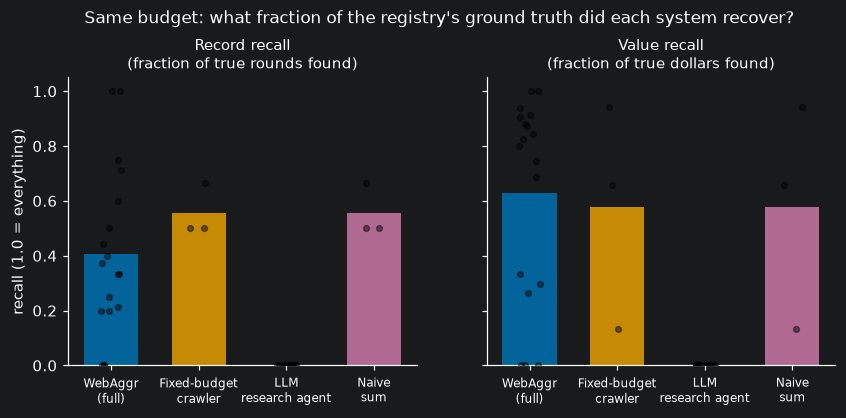

In [13]:
# Fig. 1 — recall by system (bars = means, dots = the 18 companies).
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for ax, metric, title in [(axes[0], "record_recall", "Record recall\n(fraction of true rounds found)"),
                          (axes[1], "value_recall",  "Value recall\n(fraction of true dollars found)")]:
    for i, s in enumerate(present):
        v = df[df.system == s][metric].values
        ax.bar(i, v.mean(), width=.62, color=COLORS[s], alpha=.85)
        ax.scatter(np.full(len(v), i) + np.random.uniform(-.12, .12, len(v)),
                   v, s=14, color="k", alpha=.45, zorder=3)   # one dot = one company
    ax.set_xticks(range(len(present)))
    ax.set_xticklabels([s.replace(" ", "\n", 1) for s in present], fontsize=8)
    ax.set_ylim(0, 1.05); ax.set_title(title, fontsize=10)
axes[0].set_ylabel("recall (1.0 = everything)")
fig.suptitle("Same budget: what fraction of the registry's ground truth "
             "did each system recover?", y=1.06, fontsize=11)
save(fig, "exp1_fig1_recall"); plt.show()

saved C:\Users\wangz\PycharmProjects\webagg\figures\exp1\exp1_fig2_agg_error.pdf


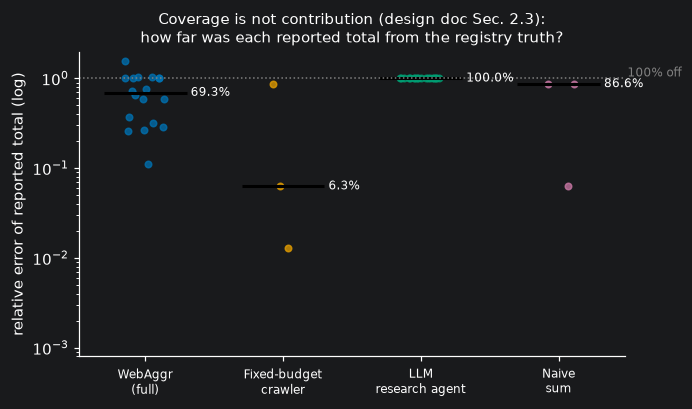

In [14]:
# Fig. 2 — aggregation error (log scale: honest about heavy tails).
fig, ax = plt.subplots(figsize=(6.4, 3.6))
FLOOR = 1e-3                                            # display floor for ~0 errors
for i, s in enumerate(present):
    v = np.maximum(df[df.system == s]["rel_error"].values, FLOOR)
    ax.scatter(np.full(len(v), i) + np.random.uniform(-.15, .15, len(v)),
               v, s=18, color=COLORS[s], alpha=.75)
    med = np.median(v)
    ax.hlines(med, i - .3, i + .3, color="k", lw=2)      # bold line = median
    ax.text(i + .33, med, f"{med:.1%}", va="center", fontsize=8)
ax.set_yscale("log"); ax.set_ylim(FLOOR * .8, None)
ax.axhline(1.0, color="grey", ls=":", lw=1)
ax.text(len(present) - .5, 1.05, "100% off", color="grey", fontsize=8)
ax.set_xticks(range(len(present)))
ax.set_xticklabels([s.replace(" ", "\n", 1) for s in present], fontsize=8)
ax.set_ylabel("relative error of reported total (log)")
ax.set_title("Coverage is not contribution (design doc Sec. 2.3):\n"
             "how far was each reported total from the registry truth?", fontsize=10)
save(fig, "exp1_fig2_agg_error"); plt.show()

saved C:\Users\wangz\PycharmProjects\webagg\figures\exp1\exp1_fig3_cost_recall.pdf


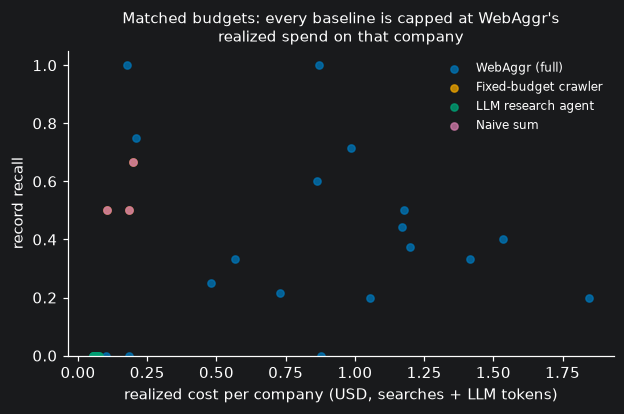

In [15]:
# Fig. 3 — the equal-cost check, visually.
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for s in present:
    d = df[df.system == s]
    ax.scatter(d.cost_usd, d.record_recall, s=22, color=COLORS[s], alpha=.8, label=s)
ax.set_xlabel("realized cost per company (USD, searches + LLM tokens)")
ax.set_ylabel("record recall"); ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, frameon=False)
ax.set_title("Matched budgets: every baseline is capped at WebAggr's\n"
             "realized spend on that company", fontsize=10)
save(fig, "exp1_fig3_cost_recall"); plt.show()

saved C:\Users\wangz\PycharmProjects\webagg\figures\exp1\exp1_fig4_intervals.pdf


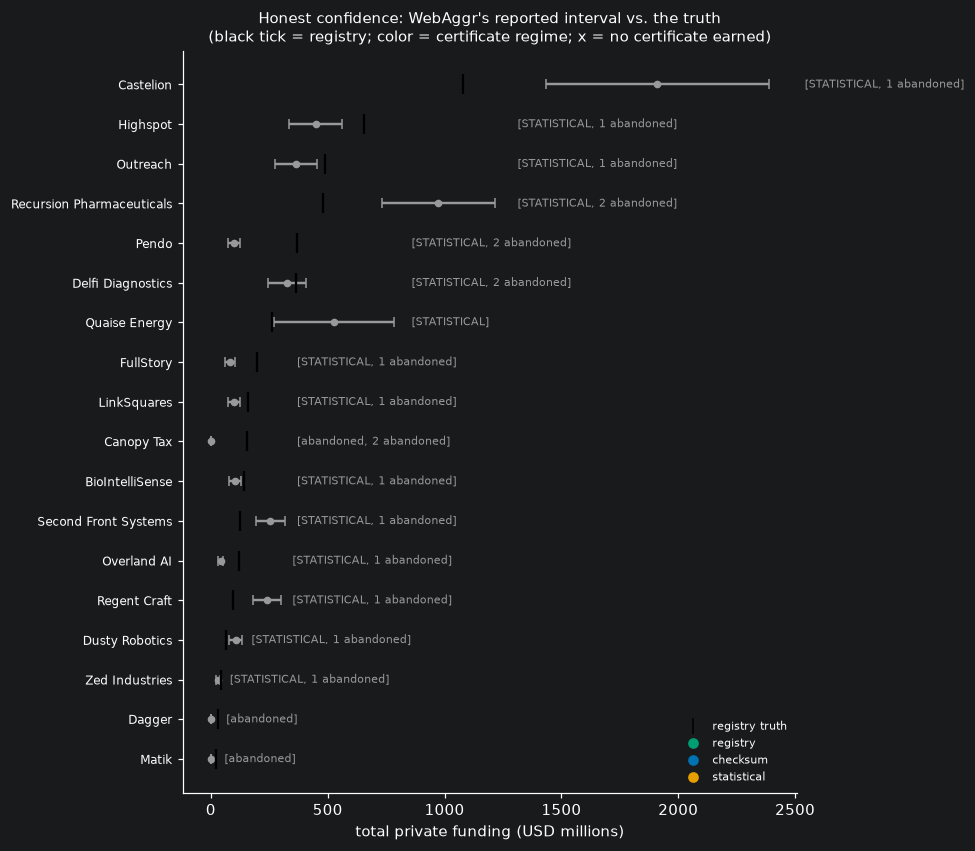

In [16]:
# Fig. 4 — WebAggr's own account of itself: interval vs. truth, per company.
wa_rows = [(r["entity_name"], r["interval"], r["true_sum"],
            Counter(g["regime"] for g in r["groups"].values()).most_common(1),
            len(r["abandoned"]))
           for r in (ledger_load("webaggr", e) for e in VAL) if r]
if wa_rows:
    wa_rows.sort(key=lambda x: x[2])
    REG_COL = {"registry": "#009E73", "checksum": "#0072B2",
               "statistical": "#E69F00"}
    fig, ax = plt.subplots(figsize=(7.2, .42 * len(wa_rows) + 1.2))
    for y, (name, iv, ts, top, n_ab) in enumerate(wa_rows):
        regime = top[0][0].split()[0] if top else "abandoned"
        col = REG_COL.get(regime, "#999999")
        ax.scatter(ts / 1e6, y, marker="|", s=180, color="k", zorder=3,
                   label="registry truth" if y == 0 else None)
        if iv["halfwidth"] is not None:
            ax.errorbar(iv["total"] / 1e6, y, xerr=iv["halfwidth"] / 1e6,
                        fmt="o", ms=4, color=col, capsize=3, lw=1.6)
        else:
            ax.scatter(iv["total"] / 1e6, y, marker="x", s=40, color=col)
        tag = f"  [{regime}" + (f", {n_ab} abandoned]" if n_ab else "]")
        ax.text(ax.get_xlim()[1], y, tag, fontsize=7, va="center", color=col)
    ax.set_yticks(range(len(wa_rows)))
    ax.set_yticklabels([w[0] for w in wa_rows], fontsize=8)
    ax.set_xlabel("total private funding (USD millions)")
    ax.set_title("Honest confidence: WebAggr's reported interval vs. the truth\n"
                 "(black tick = registry; color = certificate regime; "
                 "x = no certificate earned)", fontsize=10)
    handles = ([plt.Line2D([], [], marker="|", ls="", color="k", ms=10,
                           label="registry truth")] +
               [plt.Line2D([], [], marker="o", ls="", color=c, label=k)
                for k, c in REG_COL.items()])
    ax.legend(handles=handles, fontsize=7, frameon=False, loc="lower right")
    save(fig, "exp1_fig4_intervals"); plt.show()
else:
    print("no WebAggr results in the ledger yet")

## 12 · Reading the results

How to interpret each outcome — including the pre-registered bad ones — once the runs
are in:

**The success pattern (what the paper hopes to show).**
- Figs. 1 & 3: WebAggr's recall ≥ the crawler's at matched cost — the adaptive frontier
  and stopping rule (§3, Def. 6) spend the same money *better*, not just longer.
- Fig. 2: the gap that matters. The naive sum should be off by large multiples (every
  echo of "$40M" is added again), the crawler off whenever copies outvote an amendment
  (§4.3), the LLM agent plausible but erratic (§1: "plausible but uncertifiable"), and
  WebAggr's median error small — same web, different discipline.
- Fig. 4: intervals that contain the black tick, and groups that couldn't be certified
  saying **abandoned** instead of printing a confident wrong number. That asymmetry —
  *knowing what it doesn't know* — is the claim no baseline can make.

**The pre-registered bad outcomes (report them, don't bury them).**
- *Crawler ties WebAggr on error too* → the machinery isn't paying for itself on this
  cohort; that is a finding about the cohort's echo structure and goes in the paper.
- *Recall fine but everything abandoned* → guarantees too conservative to be useful;
  points at ε/η, feeds the frontier-depth question already on the project's horizon.
- *Intervals frequently miss the truth* → the fidelity term is mis-calibrated; this
  experiment then motivates (rather than presumes) Experiment 6's certificate.

**Caveats to carry into the writeup.**
- εF is currently the labelled App.-H fallback constant (certificate NOT CERTIFIED);
  interval widths will tighten if/when Experiment 6 lands a calibrated εF. Results are
  preliminary under the frozen A3 config.
- n = 18 companies: report per-entity dots, not just means, and avoid over-claiming
  significance; the query-diversity generalization is Experiment 8's job.
- The registry criterion is one-sided (web-known-but-unfiled events can't be graded);
  all four systems face the same asymmetry, so the *comparison* is fair even where
  absolute recall understates what a system found.

**What these runs feed next:** the frozen run DBs under `data/runs/exp1_*` are the
recorded evidence pools that Experiments 2 (stopping calibration), 4 (echo injection),
7 (ablations) and 9 (forgery margin) replay offline — no new spend.